# Benchmark OCR — Extraction de devis photovoltaïques
**Projet Alyra — comparaison Tesseract / PaddleOCR / Mistral OCR**

Ce notebook centralise :
1. Le chargement des sorties OCR (Tesseract, PaddleOCR, Mistral OCR)
2. Le calcul des métriques CER / WER par champ et par moteur
3. Les visualisations comparatives
4. Un tableau de synthèse pour la décision finale

> Mistral OCR est ajouté dès que `devis_2_mistralocr.json` est généré (voir `appeler_mistral_ocr.py`). Tant que ce fichier n'existe pas, le notebook fonctionne avec Tesseract + PaddleOCR uniquement.


## 1. Imports des librairies

In [45]:
import json
import os
import re
from pathlib import Path

import jiwer
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.dpi"] = 110


## 2. Chargement des sorties OCR

Organisation attendue : un répertoire par moteur, contenant un fichier JSON par devis.
Le **nom de fichier** (sans l'extension) est identique dans les 3 répertoires et sert
d'identifiant de devis, par ex. `tesseract/devis_2.json`, `paddleocr/devis_2.json`,
`mistralocr/devis_2.json` correspondent tous les trois au même devis `devis_2`.


In [46]:
from pathlib import Path

ENGINES_DIRS = {
    "tesseract":  "./data/tesseract",
    "paddleocr":  "./data/paddle",
    "mistralocr": "./data/mistralocr",
}

# On ignore silencieusement les répertoires qui n'existent pas encore
ENGINES_DIRS = {k: v for k, v in ENGINES_DIRS.items() if os.path.isdir(v)}
print("Moteurs disponibles pour ce run :", list(ENGINES_DIRS.keys()))

# Regrouper les fichiers par devis : devis_id -> {moteur: chemin_du_fichier}
# Le nom de fichier est identique entre répertoires, il sert directement d'identifiant.
devis_files = {}
for engine, dir_path in ENGINES_DIRS.items():
    for json_path in Path(dir_path).glob("*.json"):
        devis_id = json_path.stem
        devis_files.setdefault(devis_id, {})[engine] = str(json_path)

print(f"{len(devis_files)} devis trouvés :")
for devis_id, engines in sorted(devis_files.items()):
    print(f"  {devis_id}: {list(engines.keys())}")


Moteurs disponibles pour ce run : ['tesseract', 'paddleocr', 'mistralocr']
9 devis trouvés :
  devis_10: ['tesseract', 'paddleocr', 'mistralocr']
  devis_11: ['tesseract', 'paddleocr', 'mistralocr']
  devis_12: ['tesseract', 'paddleocr', 'mistralocr']
  devis_2: ['tesseract', 'mistralocr']
  devis_3: ['tesseract', 'paddleocr', 'mistralocr']
  devis_4: ['tesseract', 'paddleocr', 'mistralocr']
  devis_5: ['tesseract', 'paddleocr', 'mistralocr']
  devis_6: ['tesseract', 'paddleocr', 'mistralocr']
  devis_9: ['tesseract', 'paddleocr', 'mistralocr']


In [47]:
def load_engine_text(json_path, page_number=1):
    """Charge un JSON OCR et concatène tous les mots d'une page en un seul texte."""
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)
    page = next(p for p in data["pages"] if p["page_number"] == page_number)
    words = [w["text"] for w in page["words"]]
    full_text = " ".join(words)
    return full_text, data.get("duration_seconds")


def clean_markdown(text):
    """Nettoie les artefacts markdown (utile pour Mistral OCR)."""
    text = re.sub(r"\|", " ", text)
    text = re.sub(r"[#*_`]", "", text)
    text = re.sub(r"-{2,}", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# Chargement : devis_texts[devis_id][engine] = texte complet de la page 1
devis_texts = {}
engine_durations = {}  # cumul pour calculer une durée moyenne par moteur

for devis_id, engines in devis_files.items():
    devis_texts[devis_id] = {}
    for engine, path in engines.items():
        text, duration = load_engine_text(path)
        devis_texts[devis_id][engine] = clean_markdown(text)
        engine_durations.setdefault(engine, []).append(duration or 0)

print("Exemple - devis_1, tesseract :")
print(devis_texts.get("devis_2", {}).get("tesseract", "(pas encore de vérité terrain/fichier)")[:150])


Exemple - devis_1, tesseract :
Sud-Ouest ge tige Offre de prix n°: 002.143/25 Affaire : A24013 CHEVAL Devis effectué par Olivier CANTELAUBE Beautiran, le 28 Janvier 2025 SFECO 79 Ru


## 3. Textes de références par devis

Un dictionnaire par devis, qui contient le texte que chaque moteur OCR doit savoir bien identifier.
Les mots de références sont:
- Fournisseur
- client
- Date de validité ou date
- Numéro de dévis
- Total TTC


In [48]:
GOLDEN_REFERENCE = {
    "devis_2": {
        "fournisseur":          "C.M.E Sud-Ouest",
        "client":               "SFECO",
        "date":                 "le 28 Janvier 2025",
        "numero_devis":         "002.143/25",
        "total_ttc":            "16 423,20",

    },
    "devis_3": {
        "fournisseur":          "SOPRASSISTANCE",
        "client":               "SFECO SOLUTIONS",
        "date":                 "02/04/2025",
        "numero_devis":         "25040008",
        "total_ttc":            "16 116",

    },
    "devis_4": {
        "fournisseur":          "ALLOMAT",
        "client":               "SFECO SOLUTIONS",
        "date":                 "28/02/2025",
        "numero_devis":         "25-01-21740-V2",
        "total_ttc":            "",

    },
    "devis_5": {
        "fournisseur":          "TMI",
        "client":               "SFECO",
        "date":                 "20/01/2025",
        "numero_devis":         "25-01-21740-V2",
        "total_ttc":            "258 000",

    },
    "devis_6": {
        "fournisseur":          "GREEN POWER",
        "client":               "SFECO SOLUTIONS",
        "date":                 "18 février 2025",
        "numero_devis":         "SQ_09408",
        "total_ttc":            "2 006,40",

    },
    "devis_9": {
        "fournisseur":          "SigueSol",
        "client":               "SFECO",
        "date":                 "20/12/2024",
        "numero_devis":         "DEV24/12/1288",
        "total_ttc":            "1.489.141,93",

    },
    "devis_10": {
        "fournisseur":          "ELUM",
        "client":               "Sféco",
        "date":                 "12/03/2025",
        "numero_devis":         "QUO07570",
        "total_ttc":            "38 016,00",

    },
    "devis_11": {
        "fournisseur":          "MAVISUN",
        "client":               "SFECO SOLUTIONS",
        "date":                 "18/07/2025",
        "numero_devis":         "S27364",
        "total_ttc":            "94 857,60",

    },
    "devis_12": {
        "fournisseur":          "sol-direct.fr",
        "client":               "SFECO Solutions",
        "date":                 "18/07/2025",
        "numero_devis":         "13385",
        "total_ttc":            "20 160,00",

    }
}

n_champs = sum(len(v) for v in GOLDEN_REFERENCE.values())
print(f"{len(GOLDEN_REFERENCE)} devis annotés, {n_champs} champs de référence au total")


9 devis annotés, 45 champs de référence au total


## 4. Recherche de la meilleure fenêtre de texte par champ

Les moteurs segmentent différemment (mots isolés vs groupes de mots) : on ne compare
donc pas position par position, mais on cherche dans le texte complet de chaque moteur
la fenêtre de caractères qui minimise le CER par rapport à la référence.


In [49]:
def find_best_window(reference, full_text):
    ref_len = len(reference)
    best_cer = 1.0
    best_window = ""
    step = max(1, ref_len // 6)

    for start in range(0, max(1, len(full_text) - 3), step):
        for factor in (0.7, 0.85, 1.0, 1.15, 1.3):
            wlen = max(3, int(ref_len * factor))
            window = full_text[start:start + wlen].strip()
            if not window:
                continue
            cer = jiwer.cer(reference, window)
            if cer < best_cer:
                best_cer = cer
                best_window = window

    return best_window


## 5. Calcul détaillé CER / WER (avec alignement S/D/I)

Pour chaque champ et chaque moteur : on retrouve la meilleure fenêtre de texte,
puis on calcule CER et WER avec le détail des opérations (substitutions,
suppressions, insertions) via `jiwer.cer` / `jiwer.wer`.


In [50]:
rows = []

for devis_id, fields in GOLDEN_REFERENCE.items():
    if devis_id not in devis_texts:
        print(f"Attention : aucun texte OCR trouvé pour {devis_id}, ignoré.")
        continue

    for field, reference in fields.items():
        for engine, full_text in devis_texts[devis_id].items():
            matched_text = find_best_window(reference, full_text)

            cer_result = jiwer.cer(reference, matched_text)
            wer_result = jiwer.wer(reference, matched_text)

            rows.append({
                "devis": devis_id,
                "champ": field,
                "moteur": engine,
                "reference": reference,
                "texte_trouve": matched_text,
                "CER": round(cer_result, 3),
                "WER": round(wer_result, 3),
            })

df_results = pd.DataFrame(rows)
df_results



,devis,champ,moteur,reference,texte_trouve,CER,WER
0,devis_2,fournisseur,tesseract,C.M.E Sud-Ouest,C.M.E. Sud-Ouest,0.067,0.5
1,devis_2,fournisseur,mistralocr,C.M.E Sud-Ouest,C.M.E. Sud-Ouest,0.067,0.5
2,devis_2,client,tesseract,SFECO,SFECO,0.000,0.0
3,devis_2,client,mistralocr,SFECO,SFECO,0.000,0.0
4,devis_2,date,tesseract,le 28 Janvier 2025,le 28 Janvier 2025,0.000,0.0
...,...,...,...,...,...,...,...
125,devis_12,numero_devis,paddleocr,13385,13385,0.000,0.0
126,devis_12,numero_devis,mistralocr,13385,13385,0.000,0.0
127,devis_12,total_ttc,tesseract,"20 160,00","20 160,00",0.000,0.0
128,devis_12,total_ttc,paddleocr,"20 160,00","20 160,00",0.000,0.0


## 6. Synthèse par moteur (moyenne tous champs confondus)

In [51]:
summary = df_results.groupby("moteur").agg(
    CER_moyen=("CER", "mean"),
    WER_moyen=("WER", "mean"),
    n_mesures=("CER", "count"),
).round(3)

summary["duree_moyenne_sec"] = [
    round(sum(engine_durations.get(m, [0])) / max(len(engine_durations.get(m, [1])), 1), 2)
    for m in summary.index
]
summary = summary.sort_values("CER_moyen")
summary


,CER_moyen,WER_moyen,n_mesures,duree_moyenne_sec
moteur,,,,
mistralocr,0.106,0.250,45,0.96
paddleocr,0.112,0.288,40,82.50
tesseract,0.136,0.311,45,10.08


## 7. Visualisations

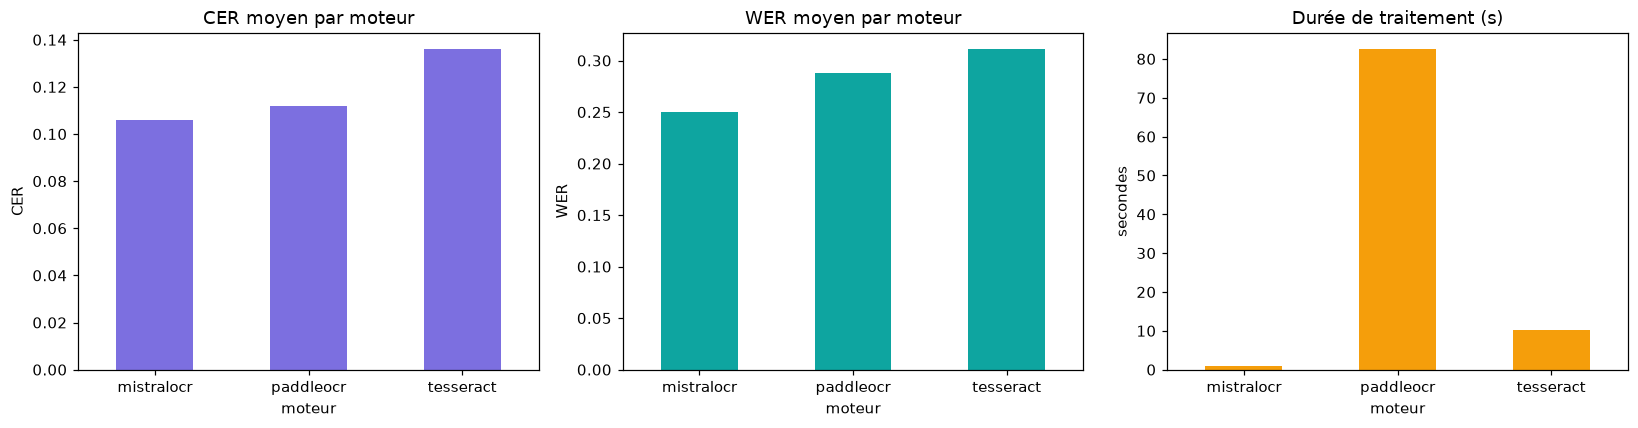

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

summary["CER_moyen"].plot(kind="bar", ax=axes[0], color="#7C6FE0")
axes[0].set_title("CER moyen par moteur")
axes[0].set_ylabel("CER")
axes[0].tick_params(axis='x', rotation=0)

summary["WER_moyen"].plot(kind="bar", ax=axes[1], color="#0EA5A0")
axes[1].set_title("WER moyen par moteur")
axes[1].set_ylabel("WER")
axes[1].tick_params(axis='x', rotation=0)

summary["duree_moyenne_sec"].plot(kind="bar", ax=axes[2], color="#F59E0B")
axes[2].set_title("Durée de traitement (s)")
axes[2].set_ylabel("secondes")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("./synthese_moteurs.png", dpi=150)
plt.show()


In [53]:
# Heatmap CER par champ x moteur — repère visuel des points faibles de chaque moteur
pivot_cer = df_results.pivot(index="champ", columns="moteur", values="CER")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(pivot_cer.values, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=0.5)

ax.set_xticks(range(len(pivot_cer.columns)))
ax.set_xticklabels(pivot_cer.columns)
ax.set_yticks(range(len(pivot_cer.index)))
ax.set_yticklabels(pivot_cer.index)

for i in range(len(pivot_cer.index)):
    for j in range(len(pivot_cer.columns)):
        val = pivot_cer.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("CER par champ et par moteur (rouge = mauvais, vert = bon)")
plt.colorbar(im, label="CER")
plt.tight_layout()
plt.savefig("/home/claude/notebook_project/heatmap_cer.png", dpi=150)
plt.show()


ValueError: Index contains duplicate entries, cannot reshape

## 8. Conclusion (à compléter au fil des devis testés)

- Compléter cette cellule après avoir testé plusieurs devis, pas uniquement `devis_2`.
- Vérifier si les échecs observés (ex : Tesseract sur les montants en italique) sont systématiques ou spécifiques à ce fournisseur.
- Ajouter le critère coût (Mistral OCR : ~4\$/1000 pages) dans l'arbitrage final.
